In [4]:
# Core libraries
import pandas as pd
import numpy as np
import json

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Project config
from src.params import *

# Plot configuration
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# General outline for EDA 

### Phase I: Data Quality
**To look at:**
- Overall aspect of sample PM2.5 curves
- % day availability per city/sensor
- Number, max length and distribution across the train set of missing days
- time distribution of sensors
- Distribution of intra-day coverage per sensor
- Aberrant values (high or low), frequency and distribution across train set

**Output:**
- Threshold for filtering out sensors with day availability below x% of total days
- Decision on max gap length acceptable (interpolation vs suppression)
- List of cities to remove because insufficient data quality
- Decision on handling aberrant data
- First city reduction based on data quality (target: 5-7 cities from 12)


### Phase II: Sensor Metrics and Aggregation
**To look at:**
- Correlation between same-city sensors
- Inter-sensor variance
- Temporal stability of sensors

**Output:**
- Coverage threshold per day for filtering out unreliable sensors (if needed)
- min sensors to keep a city
- Rule of aggregation: simple average? weighted average by coverage?
- further reduction of city based on sensors availability

### Phase III: Target Distribution
**To look at:**
- Shape of PM2.5 distributions (after sensor aggregation)
- Distribution of values 
- Outliers detection and frequency

**Output:**
- Decision on log transformation
- Choice of metric: RMSE vs RMSLE vs MAE 


### Phase IV: Temporal Patterns
**To look at:**
- Trend over time
- Seasonality (monthly patterns)
- Distribution of day-to-day changes
- Volatility: rolling std sur 7d/30d 

**Output:**
- Knowledge about general behavior, extreme periods
- Decision on retraining frequency 


### Phase V: Autocorrelation
**To look at:**
- ACF/PACF plots per city
- Identification of significant lags

**Output:**
- Relevant lookback window (e.g., 7 days, 14 days, 30 days)
- List of lags to include as features (e.g., all individual lags from 1 to 7, or specific lags: 1, 7, 14, 30)
- Alternative: decision on using rolling features (mean/std) vs individual lags


### Phase VI: Inter-City Comparison
**To look at:**
- Value distributions between cities
- Temporal patterns comparison across cities
- Cross-correlation between cities (pattern similarity)

**Output:**
- Decision on model architecture: 1 global model + city feature OR separate models per city
- Final city selection: keep 5-7 cities with best data quality 


# Quality check 
- missing days : number, max duration, distribution
- aberrant values (negatives)
- decision on filtering out sensors and cities

In [55]:
#loading df
df_weather = pd.read_csv("../data/raw/weather.csv")
df_airqual = pd.read_csv("../data/raw/aq_data.csv")

In [63]:
#convert date in pd datetime format
df_weather["date"] = pd.to_datetime(df_weather["date"])
df_airqual["date"] = pd.to_datetime(df_airqual["date_from_local"].str[:10])


In [69]:
#check no missing days in weather
df_weather["date"].dt.day.diff()

0       NaN
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
7305    1.0
7306    1.0
7307    1.0
7308    1.0
7309    1.0
Name: date, Length: 7310, dtype: float64

In [71]:
df_airqual.head()

,sensor_id,date_from_utc,date_from_local,date_to_utc,date_to_local,pm25_avg,pm25_min,pm25_q25,pm25_median,pm25_q75,pm25_max,coverage,city,date
0,1582598,2023-04-30T22:00:00Z,2023-05-01T00:00:00+02:00,2023-05-01T22:00:00Z,2023-05-02T00:00:00+02:00,16.00,4.9,10.675,15.05,19.650,32.0,100.0,Paris,2023-05-01
1,1582598,2023-05-01T22:00:00Z,2023-05-02T00:00:00+02:00,2023-05-02T22:00:00Z,2023-05-03T00:00:00+02:00,12.60,6.6,9.650,10.90,15.600,21.9,100.0,Paris,2023-05-02
2,1582598,2023-05-02T22:00:00Z,2023-05-03T00:00:00+02:00,2023-05-03T22:00:00Z,2023-05-04T00:00:00+02:00,11.60,4.8,9.900,12.25,13.800,17.6,100.0,Paris,2023-05-03
3,1582598,2023-05-03T22:00:00Z,2023-05-04T00:00:00+02:00,2023-05-04T22:00:00Z,2023-05-05T00:00:00+02:00,8.96,3.9,7.825,9.40,10.700,11.9,100.0,Paris,2023-05-04
4,1582598,2023-05-04T22:00:00Z,2023-05-05T00:00:00+02:00,2023-05-05T22:00:00Z,2023-05-06T00:00:00+02:00,5.07,0.4,3.875,4.65,6.425,9.6,100.0,Paris,2023-05-05


In [ ]:
#check number, duration,istribution of gaps in airqual
df_airqual["delta"] = df_airqual.groupby("sensor_id")["date"].diff().dt.days
gaps = df_airqual[df_airqual["delta"] > 1]
gap_stats= gaps.groupby(["city", "sensor_id"])["delta"].agg(["count", "max", "median"])
gap_stats

count   max  median
city        sensor_id                     
Barcelona   4273113       53  35.0     2.0
Berlin      1300111        8   7.0     3.0
            1300115        8   7.0     3.0
            1300119       10   7.0     3.0
London      249            9  11.0     2.0
            28890         17   6.0     3.0
            1304692        4  11.0     9.5
            1304737        6   4.0     3.0
            1561901       12  27.0     6.5
            1666368       13  12.0     7.0
            6933605        2   5.0     3.5
Los Angeles 25196          4  30.0     4.0
Lyon        7922          26   7.0     2.0
            8559           8   7.0     2.0
            24867          8   7.0     2.5
New York    673            2   6.0     4.0
            1097           3  54.0     6.0
            1102           8   5.0     2.0
            1534           4   7.0     3.5
            1662910        1   6.0     6.0
Paris       9548          24   7.0     2.0
            1562368       23   7.0     2.0
            1582598       22  16.0     2.0
Rome        21806         15   8.0     2.0
            21841         34  13.0     2.5
            21846         23   5.0     2.0
            21857         23  13.0     3.0
Santiago    3190           8  51.0     2.0
            4100          10  28.0     2.0

In [ ]:
#vizualisation histogram distribution gaps

def plot_gap_histograms(df= gaps, gap_col="delta", sensor_col="sensor_id", bins=30):
    sensors = gaps[sensor_col].dropna().unique() #get sensor list (usually wihtout na and duplicate but..)
    ncols = 4
    nrows = len(sensors) // ncols + 1

    fig, axes = plt.subplots(nrows, ncols, figsize=(8, 12))
    axes = axes.flatten()

    for i, sensor_id in enumerate(sensors):
        data = df[df["sensor_id"] == sensor_id][gap_col] #get gap data
        city = df[df["sensor_id"] == sensor_id]["city"].iloc[0]
        axes[i].hist(data, bins=bins, edgecolor="black", alpha=0.7)
        axes[i].set_title(f"{city}_sensor-{sensor_id}")



    plt.tight_layout()
    plt.show()
    plot_gap_histograms(gaps, gap_col="delta", sensor_col="sensor_id", bins=20)

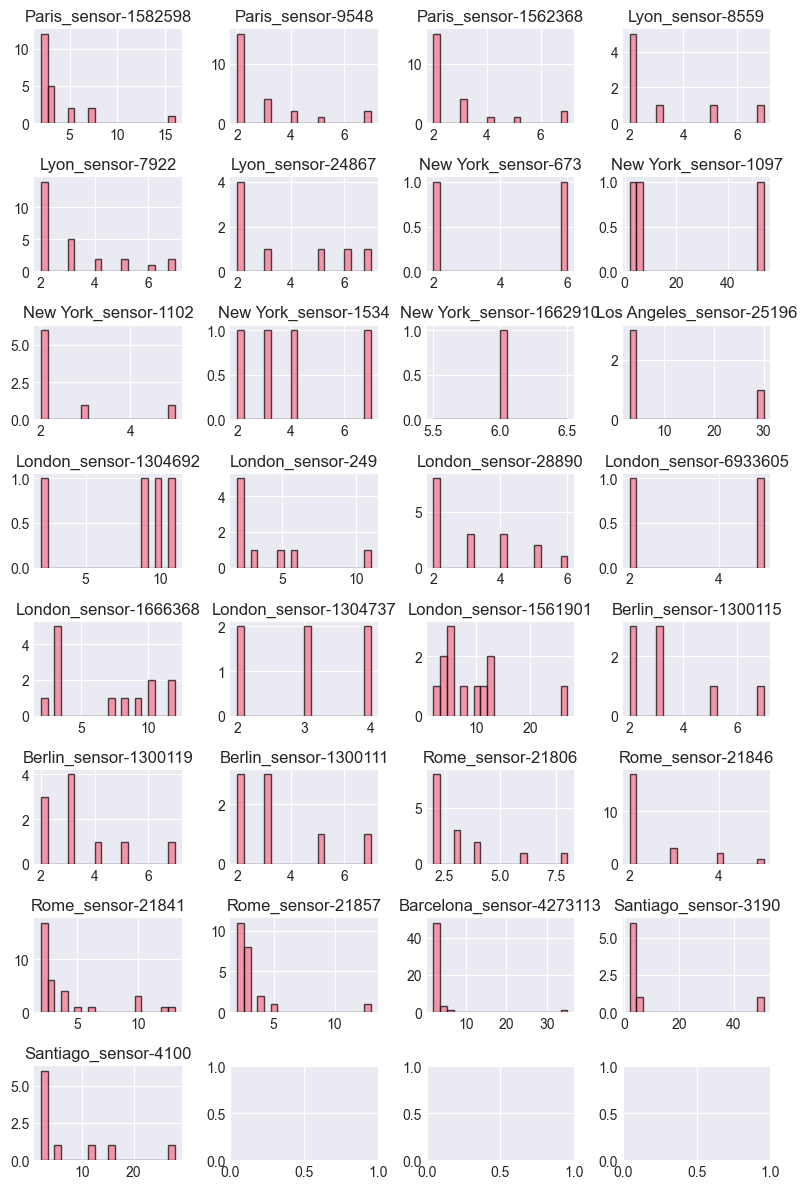

In [ ]:
#check distri

In [ ]:
#visualization gaps pver train set

,sensor_id,date_from_utc,date_from_local,date_to_utc,date_to_local,pm25_avg,pm25_min,pm25_q25,pm25_median,pm25_q75,pm25_max,coverage,city,date
22,1582598,2023-05-24T22:00:00Z,2023-05-25T00:00:00+02:00,2023-05-25T22:00:00Z,2023-05-26T00:00:00+02:00,12.20,8.3,12.400000,12.50,13.275,14.000000,25.0,Paris,2023-05-25
35,1582598,2023-06-07T22:00:00Z,2023-06-08T00:00:00+02:00,2023-06-08T22:00:00Z,2023-06-09T00:00:00+02:00,17.90,13.7,16.299999,16.85,19.500,23.200001,25.0,Paris,2023-06-08
60,1582598,2023-07-03T22:00:00Z,2023-07-04T00:00:00+02:00,2023-07-04T22:00:00Z,2023-07-05T00:00:00+02:00,8.96,5.1,8.225000,9.25,10.175,11.300000,33.0,Paris,2023-07-04
61,1582598,2023-07-19T22:00:00Z,2023-07-20T00:00:00+02:00,2023-07-20T22:00:00Z,2023-07-21T00:00:00+02:00,8.38,1.5,7.050000,8.85,9.525,13.000000,50.0,Paris,2023-07-20
98,1582598,2023-08-26T22:00:00Z,2023-08-27T00:00:00+02:00,2023-08-27T22:00:00Z,2023-08-28T00:00:00+02:00,4.50,4.5,4.500000,4.50,4.500,4.500000,4.0,Paris,2023-08-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21001,4100,2024-05-08T04:00:00Z,2024-05-08T00:00:00-04:00,2024-05-09T04:00:00Z,2024-05-09T00:00:00-04:00,24.60,22.0,22.000000,23.00,26.000,32.000000,71.0,Santiago,2024-05-08
21088,4100,2024-08-14T04:00:00Z,2024-08-14T00:00:00-04:00,2024-08-15T04:00:00Z,2024-08-15T00:00:00-04:00,37.40,32.0,33.000000,35.00,42.000,46.000000,71.0,Santiago,2024-08-14
21103,4100,2024-08-30T04:00:00Z,2024-08-30T00:00:00-04:00,2024-08-31T04:00:00Z,2024-08-31T00:00:00-04:00,20.80,20.0,20.000000,20.00,20.750,26.000000,92.0,Santiago,2024-08-30
21110,4100,2024-09-07T04:00:00Z,2024-09-07T00:00:00-04:00,2024-09-08T04:00:00Z,2024-09-08T01:00:00-03:00,22.10,18.0,19.000000,23.00,24.000,28.000000,88.0,Santiago,2024-09-07


# merging weather and air qual 

In [12]:
#check that no missing days in weather df
df_weather["date"].nunique()/(df_weather.shape[0] / df_weather["city"].nunique())

1.0

In [17]:
#merge df matching cities and date, leaving any missing day as NaN for further investigation
df_merged = pd.merge(df_airqual, df_weather, on=["date", "city"], how= "outer")

In [18]:
df_merged.columns
new_order = ["city", "sensor_id","date", 'pm25_avg', 'pm25_min', 'pm25_q25', 'pm25_median',
       'pm25_q75', 'pm25_max', 'coverage','temp_min',
       'temp_max', 'temp_avg', 'cloud_cover', 'humidity', 'precipitation',
       'pressure', 'wind_speed', 'wind_direction' ]
df_merged = df_merged[new_order]

In [50]:
df = df_merged.sort_values(by= ["city", "sensor_id", "date"], ascending= True)

In [ ]:

#ok

np.int64(0)

In [54]:
df[df["city"] == "Santiago"]

,city,sensor_id,date,pm25_avg,pm25_min,pm25_q25,pm25_median,pm25_q75,pm25_max,coverage,temp_min,temp_max,temp_avg,cloud_cover,humidity,precipitation,pressure,wind_speed,wind_direction
28,Santiago,3190.0,2023-05-01,38.9,26.0,37.00,40.5,42.25,44.0,100.0,5.88,17.90,11.890,24.0,52.0,0.0,989.0,4.12,170.0
58,Santiago,3190.0,2023-05-02,36.4,31.0,33.75,37.0,39.00,42.0,100.0,4.84,19.31,12.075,0.0,41.0,0.0,985.0,2.57,50.0
88,Santiago,3190.0,2023-05-03,46.5,42.0,46.00,47.0,48.00,48.0,100.0,8.13,19.90,14.015,0.0,42.0,0.0,992.0,5.14,160.0
118,Santiago,3190.0,2023-05-04,41.3,38.0,39.00,41.0,43.25,46.0,100.0,5.17,19.12,12.145,0.0,55.0,0.0,995.0,4.63,190.0
148,Santiago,3190.0,2023-05-05,59.7,47.0,56.50,62.5,64.00,66.0,100.0,5.84,21.18,13.510,73.0,35.0,0.0,948.0,6.17,170.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6198,Santiago,NaN,2023-12-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.73,26.49,19.610,100.0,51.0,0.0,1016.0,6.69,210.0
6228,Santiago,NaN,2023-12-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.28,29.67,22.475,5.0,35.0,0.0,945.0,6.69,170.0
6258,Santiago,NaN,2023-12-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.49,29.42,22.955,0.0,34.0,0.0,975.0,8.75,220.0
6288,Santiago,NaN,2023-12-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.87,25.38,19.125,0.0,40.0,0.0,947.0,7.72,170.0


In [ ]:
#no missing days in weather so counting NaN resulting from outermerge with give uss the number of days
missing_days = pd.DataFrame()
for city in df_merged["city"].unique():
    missing_days["city"] = city


,city,sensor_id,date,pm25_avg,pm25_min,pm25_q25,pm25_median,pm25_q75,pm25_max,coverage,temp_min,temp_max,temp_avg,cloud_cover,humidity,precipitation,pressure,wind_speed,wind_direction
21062,Paris,1582598.0,2025-04-11,14.90,14.9,14.900,14.90,14.900,14.9,4.0,5.42,21.58,13.500,0.0,56.0,0.00,1023.0,5.14,60.0
21063,Paris,9548.0,2025-04-11,14.70,14.7,14.700,14.70,14.700,14.7,4.0,5.42,21.58,13.500,0.0,56.0,0.00,1023.0,5.14,60.0
21064,Paris,1562368.0,2025-04-11,17.80,17.8,17.800,17.80,17.800,17.8,4.0,5.42,21.58,13.500,0.0,56.0,0.00,1023.0,5.14,60.0
21091,Paris,NaN,2025-04-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.20,21.52,15.360,0.0,45.0,1.84,1008.0,8.23,160.0
21118,Paris,1582598.0,2025-04-13,10.90,10.9,10.900,10.90,10.900,10.9,4.0,12.53,17.56,15.045,75.0,81.0,0.67,1008.0,6.17,230.0
21119,Paris,9548.0,2025-04-13,8.70,8.7,8.700,8.70,8.700,8.7,4.0,12.53,17.56,15.045,75.0,81.0,0.67,1008.0,6.17,230.0
21120,Paris,1562368.0,2025-04-13,7.10,7.1,7.100,7.10,7.100,7.1,4.0,12.53,17.56,15.045,75.0,81.0,0.67,1008.0,6.17,230.0
21148,Paris,1582598.0,2025-04-14,8.15,2.8,6.775,9.65,9.975,10.9,25.0,7.03,20.51,13.770,75.0,62.0,0.00,1008.0,5.66,200.0
21149,Paris,9548.0,2025-04-14,13.60,7.6,10.875,14.30,16.450,18.6,25.0,7.03,20.51,13.770,75.0,62.0,0.00,1008.0,5.66,200.0
21150,Paris,1562368.0,2025-04-14,11.90,6.5,10.425,11.85,13.575,16.8,25.0,7.03,20.51,13.770,75.0,62.0,0.00,1008.0,5.66,200.0


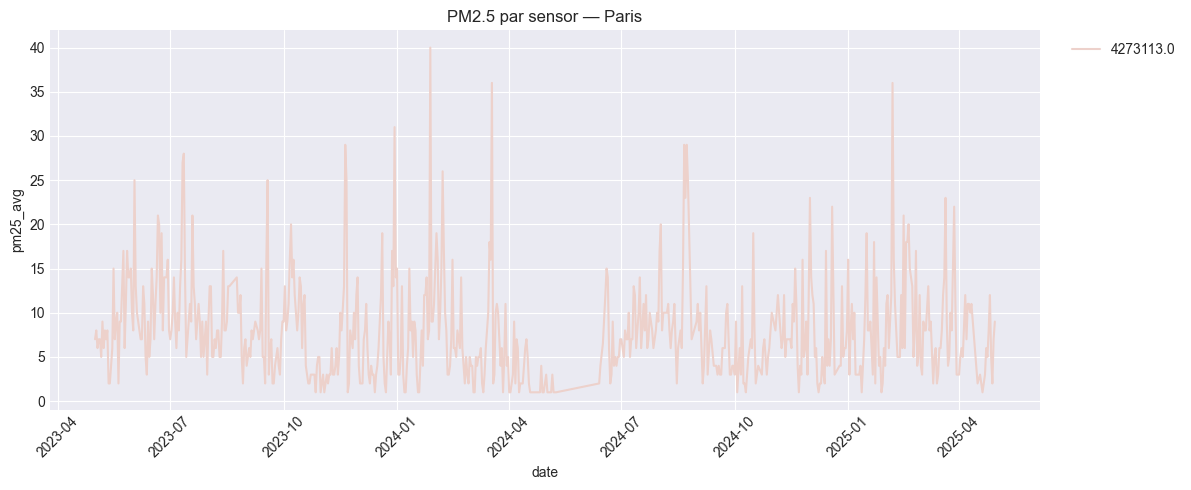

In [93]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_merged[df_merged['city'] == 'Barcelona'], x='date', y='pm25_avg', hue='sensor_id')
plt.title('PM2.5 par sensor — Paris')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##